# 05 — Diffusion Model (DDPM): Inverse Design of Underwater Acoustic Coatings

## Overview
This notebook implements a **Conditional Denoising Diffusion Probabilistic Model (DDPM)** for inverse design.

**Key idea**: Starting from pure Gaussian noise, the model iteratively denoises a 20-dimensional parameter vector, conditioned on the target absorption value. Over T=500 diffusion steps, the noisy vector is progressively refined into a physically meaningful design.

**Forward process**: Gradually add noise to parameter vectors over T steps.  
**Reverse process**: A neural network predicts the noise component at each step, conditioned on the target absorption.  
**Loss**: Simple MSE between predicted and actual noise.

By sampling different initial noise vectors, the model generates **diverse designs** for the same target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time, math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ---- Force NVIDIA GPU ----
assert torch.cuda.is_available(), (
    "CUDA not available! Install PyTorch with CUDA support:\n"
    "  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121"
)
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

GPU : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.0 GB


## TMM Forward Model

In [2]:
RHO_WATER=1000.0; C_WATER=1500.0; Z_WATER=RHO_WATER*C_WATER; W_FILM=2.0
HOLLOW_MAP={1:0,2:1,4:2,5:3,7:4,8:5}
PARAM_COLUMNS=[f'd{i}' for i in range(1,11)]+['m2','m3','m5','m6','m8','m9']+['rho','eta','E','nu']
PARAM_BOUNDS=np.array([[1,20]]*10+[[20,1980]]*6+[[1000,1500],[.1,.8],[1e7,1e8],[.4,.49]])

def tmm_forward(params):
    d_mm=np.asarray(params[:10],dtype=float); m_mm=np.asarray(params[10:16],dtype=float)
    rho_r,eta,E_r,nu=float(params[16]),float(params[17]),float(params[18]),float(params[19])
    d_m,m_m=d_mm/1e3,m_mm/1e3; Ec=E_r*(1+1j*eta)
    lam=(Ec*nu)/((1+nu)*(1-2*nu)); mu=Ec/(2*(1+nu))
    s=0.0
    for f in range(1,1001):
        w=2*np.pi*f; T=np.eye(2,dtype=complex)
        for i in range(10):
            eps=m_m[HOLLOW_MAP[i]]/W_FILM if i in HOLLOW_MAP else 0.0
            re=rho_r*(1-eps**2)
            num=mu*(lam+2*mu)*(eps**2+1)+2*eps**2*lam; den=(lam+mu)*eps**2+mu
            Se=num/den if abs(den)>1e-15 else num*1e15
            ce=np.sqrt(Se/re); k=w/ce; Ze=re*ce
            ck,sk=np.cos(k*d_m[i]),np.sin(k*d_m[i])
            t21=1j*sk/Ze if abs(Ze)>1e-15 else 1e15+0j
            T=T@np.array([[ck,1j*Ze*sk],[t21,ck]],dtype=complex)
        if abs(T[1,0])<1e-15: R=1.0
        else: Zi=T[0,0]/T[1,0]; R=(Zi-Z_WATER)/(Zi+Z_WATER) if abs(Zi)<1e15 else 1.0
        a=1-abs(R)**2; s+=max(0,min(1,a.real if hasattr(a,'real') else a))
    return s/1000

print(f'Base-case: {tmm_forward([10]*10+[1000]*6+[1130,.4,5e7,.44]):.4f}')

Base-case: 0.3002


## Data Loading

In [3]:
df = pd.read_csv('../data/lhs_data.csv')
param_cols=[c for c in df.columns if c!='Average_Absorption']
X=df[param_cols].values; y=df['Average_Absorption'].values

X_tr,X_tmp,y_tr,y_tmp=train_test_split(X,y,test_size=0.2,random_state=42)
X_val,X_te,y_val,y_te=train_test_split(X_tmp,y_tmp,test_size=0.5,random_state=42)

ps=MinMaxScaler(); X_tr_n=ps.fit_transform(X_tr); X_val_n=ps.transform(X_val); X_te_n=ps.transform(X_te)
as_=MinMaxScaler(); y_tr_n=as_.fit_transform(y_tr.reshape(-1,1)).ravel()
y_val_n=as_.transform(y_val.reshape(-1,1)).ravel(); y_te_n=as_.transform(y_te.reshape(-1,1)).ravel()

BS = 256
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr_n, dtype=torch.float32),
                  torch.tensor(y_tr_n, dtype=torch.float32)),
    batch_size=BS, shuffle=True, pin_memory=True, num_workers=0
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_n, dtype=torch.float32),
                  torch.tensor(y_val_n, dtype=torch.float32)),
    batch_size=BS, shuffle=False, pin_memory=True, num_workers=0
)
print(f'Train:{X_tr.shape[0]}  Val:{X_val.shape[0]}  Test:{X_te.shape[0]}')

Train:80000  Val:10000  Test:10000


## Diffusion Utilities

In [4]:
T_STEPS = 500

# Linear beta schedule
betas = torch.linspace(1e-4, 0.02, T_STEPS).to(device)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)  # cumulative product
alpha_bar_prev = torch.cat([torch.tensor([1.0], device=device), alpha_bar[:-1]])

# Precompute coefficients
sqrt_alpha_bar = torch.sqrt(alpha_bar)
sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)
sqrt_recip_alpha = 1.0 / torch.sqrt(alphas)
beta_tilde = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)  # posterior variance


def q_sample(x0, t, noise=None):
    """Forward process: add noise to x0 at timestep t."""
    if noise is None:
        noise = torch.randn_like(x0)
    a_bar_t = sqrt_alpha_bar[t].unsqueeze(-1)  # (B, 1)
    s_t = sqrt_one_minus_alpha_bar[t].unsqueeze(-1)
    return a_bar_t * x0 + s_t * noise, noise


def sinusoidal_embedding(t, dim=64):
    """Sinusoidal positional embedding for timesteps."""
    half = dim // 2
    freq = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / half)
    args = t.float().unsqueeze(-1) * freq.unsqueeze(0)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

## Noise Prediction Network

In [5]:
TIME_DIM = 64
COND_DIM = 64

class NoisePredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(TIME_DIM, TIME_DIM), nn.SiLU(),
        )
        self.cond_embed = nn.Sequential(
            nn.Linear(1, COND_DIM), nn.SiLU(),
        )
        input_dim = 20 + TIME_DIM + COND_DIM  # 148
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 128), nn.SiLU(),
            nn.Linear(128, 20),
        )

    def forward(self, x_noisy, t, cond):
        """
        x_noisy: (B, 20)
        t: (B,) integer timesteps
        cond: (B,) normalised absorption
        """
        t_emb = self.time_embed(sinusoidal_embedding(t, TIME_DIM))  # (B, 64)
        c_emb = self.cond_embed(cond.unsqueeze(-1))                  # (B, 64)
        h = torch.cat([x_noisy, t_emb, c_emb], dim=-1)              # (B, 148)
        return self.net(h)


model = NoisePredictor().to(device)
print(f'Diffusion model parameters: {sum(p.numel() for p in model.parameters()):,}')

Diffusion model parameters: 209,492


## Training

In [6]:
EPOCHS = 300
optimizer = optim.Adam(model.parameters(), lr=2e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# EMA
ema_decay = 0.999
ema_model = NoisePredictor().to(device)
ema_model.load_state_dict(model.state_dict())

def update_ema(ema_m, m, decay=0.999):
    with torch.no_grad():
        for ep, p in zip(ema_m.parameters(), m.parameters()):
            ep.data.mul_(decay).add_(p.data, alpha=1-decay)

train_losses, val_losses = [], []

print('Training DDPM ...')
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    run, n = 0., 0
    for params_b, abs_b in train_loader:
        params_b, abs_b = params_b.to(device), abs_b.to(device)
        B = params_b.size(0)

        # Sample random timesteps
        t = torch.randint(0, T_STEPS, (B,), device=device)

        # Add noise
        noise = torch.randn_like(params_b)
        x_noisy = sqrt_alpha_bar[t].unsqueeze(-1) * params_b + sqrt_one_minus_alpha_bar[t].unsqueeze(-1) * noise

        # Predict noise
        pred_noise = model(x_noisy, t, abs_b)
        loss = nn.functional.mse_loss(pred_noise, noise)

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        update_ema(ema_model, model, ema_decay)
        run += loss.item() * B; n += B

    train_losses.append(run / n)

    # Validation
    model.eval()
    vr, vn = 0., 0
    with torch.no_grad():
        for pb, ab in val_loader:
            pb, ab = pb.to(device), ab.to(device)
            B = pb.size(0)
            t = torch.randint(0, T_STEPS, (B,), device=device)
            noise = torch.randn_like(pb)
            xn = sqrt_alpha_bar[t].unsqueeze(-1)*pb + sqrt_one_minus_alpha_bar[t].unsqueeze(-1)*noise
            pn = ema_model(xn, t, ab)
            vr += nn.functional.mse_loss(pn, noise).item()*B; vn += B
    val_losses.append(vr / vn)
    scheduler.step()

    if epoch % 50 == 0:
        print(f'  Epoch {epoch:3d}  train={train_losses[-1]:.6f}  val={val_losses[-1]:.6f}')

train_time = time.time() - t0
print(f'Done in {train_time:.1f}s')

Training DDPM ...
  Epoch  50  train=0.157353  val=0.156182
  Epoch 100  train=0.156362  val=0.155630
  Epoch 150  train=0.154062  val=0.159365
  Epoch 200  train=0.154316  val=0.149609
  Epoch 250  train=0.154401  val=0.155655
  Epoch 300  train=0.155227  val=0.151701
Done in 642.3s


## Sampling (Reverse Process)

In [7]:
@torch.no_grad()
def sample_ddpm(cond, n_samples=1):
    """
    Generate designs by iteratively denoising.

    cond: (N,) normalised absorption targets
    n_samples: number of independent samples per target
    Returns: (N, n_samples, 20)
    """
    N = cond.shape[0]
    ema_model.eval()
    all_samples = []

    for _ in range(n_samples):
        x = torch.randn(N, 20, device=device)  # start from noise

        for t_val in reversed(range(T_STEPS)):
            t_batch = torch.full((N,), t_val, device=device, dtype=torch.long)
            pred_noise = ema_model(x, t_batch, cond)

            # Reverse step
            alpha_t = alphas[t_val]
            alpha_bar_t = alpha_bar[t_val]
            beta_t = betas[t_val]

            mean = sqrt_recip_alpha[t_val] * (
                x - beta_t / sqrt_one_minus_alpha_bar[t_val] * pred_noise
            )

            if t_val > 0:
                noise = torch.randn_like(x)
                sigma = torch.sqrt(beta_tilde[t_val])
                x = mean + sigma * noise
            else:
                x = mean

        all_samples.append(x.clamp(0, 1).cpu().numpy())

    return np.stack(all_samples, axis=1)  # (N, n_samples, 20)

In [8]:
N_VAL = 200
N_SAMPLES = 10

print(f'Sampling {N_SAMPLES} designs for {N_VAL} targets ({T_STEPS} steps each) ...')
cond_t = torch.tensor(y_te_n[:N_VAL], dtype=torch.float32).to(device)
t0_s = time.time()
generated = sample_ddpm(cond_t, n_samples=N_SAMPLES)
sample_time = time.time() - t0_s
print(f'Sampling done in {sample_time:.1f}s. Shape: {generated.shape}')

Sampling 10 designs for 200 targets (500 steps each) ...
Sampling done in 5.9s. Shape: (200, 10, 20)


## Physics Validation

In [9]:
target_abs = y_te[:N_VAL]
best_recon = np.zeros(N_VAL)
all_recon  = np.zeros((N_VAL, N_SAMPLES))

for i in range(N_VAL):
    for j in range(N_SAMPLES):
        phys = ps.inverse_transform(generated[i, j].reshape(1, -1))[0]
        all_recon[i, j] = tmm_forward(phys)
    errors = np.abs(all_recon[i] - target_abs[i])
    best_recon[i] = all_recon[i, np.argmin(errors)]

recon_mse = mean_squared_error(target_abs, best_recon)
recon_mae = mean_absolute_error(target_abs, best_recon)
recon_r2  = r2_score(target_abs, best_recon)
diversity = all_recon.std(axis=1).mean()

print(f'Best-of-{N_SAMPLES}  MSE={recon_mse:.6f}  MAE={recon_mae:.4f}  R²={recon_r2:.4f}')
print(f'Diversity (std): {diversity:.4f}')

Best-of-10  MSE=0.000051  MAE=0.0051  R²=0.9971
Diversity (std): 0.0418


## Visualisation

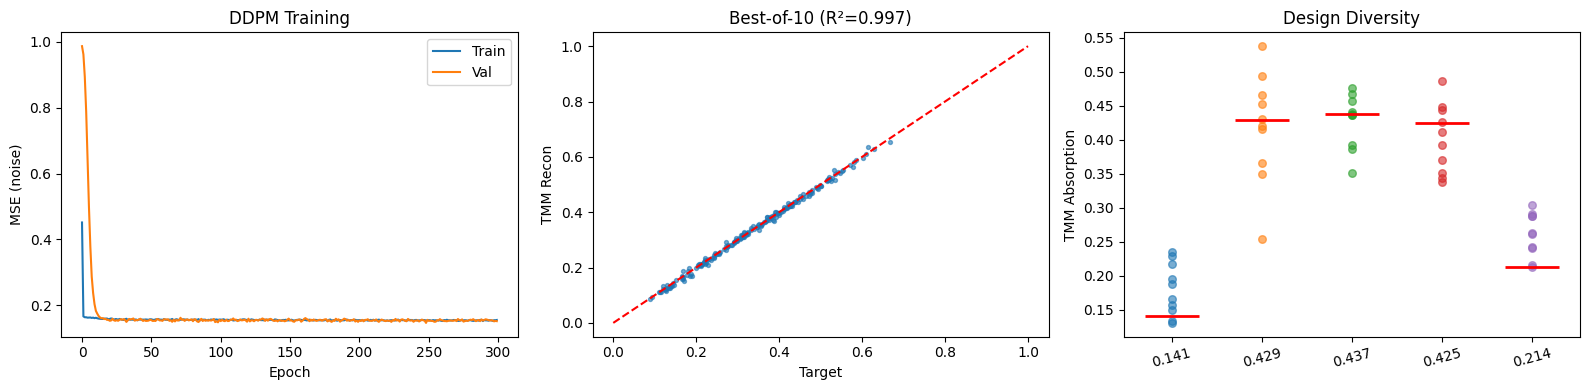

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax=axes[0]; ax.plot(train_losses,label='Train'); ax.plot(val_losses,label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (noise)'); ax.set_title('DDPM Training'); ax.legend()

ax=axes[1]; ax.scatter(target_abs,best_recon,s=8,alpha=.6); ax.plot([0,1],[0,1],'r--')
ax.set_xlabel('Target'); ax.set_ylabel('TMM Recon'); ax.set_title(f'Best-of-{N_SAMPLES} (R²={recon_r2:.3f})')

# Diversity
ax=axes[2]
idx=np.linspace(0,N_VAL-1,5,dtype=int)
for ii,ix in enumerate(idx):
    ax.scatter([ii]*N_SAMPLES,all_recon[ix],alpha=.6,s=30)
    ax.hlines(target_abs[ix],ii-.3,ii+.3,colors='red',lw=2)
ax.set_xticks(range(5)); ax.set_xticklabels([f'{target_abs[ix]:.3f}' for ix in idx],rotation=15)
ax.set_ylabel('TMM Absorption'); ax.set_title('Design Diversity')

plt.tight_layout(); plt.show()

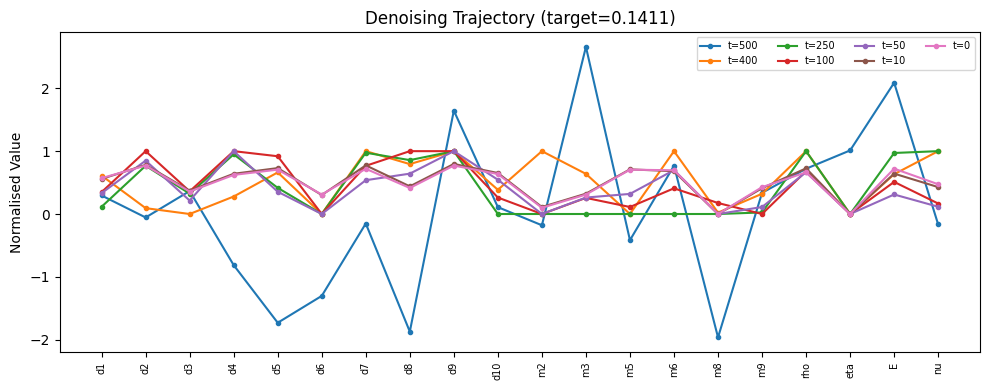

In [11]:
# Denoising trajectory visualisation for a single target
@torch.no_grad()
def sample_with_trajectory(cond_val_norm, checkpoints=[500, 400, 250, 100, 50, 10, 0]):
    """Sample one design, recording the parameter state at checkpoint timesteps."""
    ema_model.eval()
    cond = torch.tensor([cond_val_norm], dtype=torch.float32).to(device)
    x = torch.randn(1, 20, device=device)
    traj = {T_STEPS: x.cpu().numpy().flatten()}

    for t_val in reversed(range(T_STEPS)):
        t_b = torch.full((1,), t_val, device=device, dtype=torch.long)
        pn = ema_model(x, t_b, cond)
        mean = sqrt_recip_alpha[t_val] * (x - betas[t_val]/sqrt_one_minus_alpha_bar[t_val]*pn)
        if t_val > 0:
            x = mean + torch.sqrt(beta_tilde[t_val]) * torch.randn_like(x)
        else:
            x = mean
        if t_val in checkpoints:
            traj[t_val] = x.clamp(0, 1).cpu().numpy().flatten()

    return traj

traj = sample_with_trajectory(y_te_n[0])

fig, ax = plt.subplots(figsize=(10, 4))
for t_val, vals in sorted(traj.items(), reverse=True):
    ax.plot(range(20), vals, 'o-', markersize=3, label=f't={t_val}')
ax.set_xticks(range(20)); ax.set_xticklabels(PARAM_COLUMNS, rotation=90, fontsize=7)
ax.set_ylabel('Normalised Value'); ax.set_title(f'Denoising Trajectory (target={y_te[0]:.4f})')
ax.legend(fontsize=7, ncol=4); plt.tight_layout(); plt.show()

## Results Summary

In [12]:
results = {
    'method': 'DDPM',
    'recon_mse': float(recon_mse),
    'recon_mae': float(recon_mae),
    'recon_r2': float(recon_r2),
    'diversity_std': float(diversity),
    'can_generate_diverse': True,
    'training_time_seconds': round(train_time, 1),
    'sampling_time_seconds': round(sample_time, 1),
}
print(results)

{'method': 'DDPM', 'recon_mse': 5.1436556061347724e-05, 'recon_mae': 0.005081614798922669, 'recon_r2': 0.9970923748228775, 'diversity_std': 0.04175383753085373, 'can_generate_diverse': True, 'training_time_seconds': 642.3, 'sampling_time_seconds': 5.9}


### Discussion

The DDPM generates designs by iteratively refining noise into structured parameter vectors. The denoising trajectory provides an interpretable view of how the model transitions from random noise to a meaningful design.

**Advantages**: Naturally multimodal — different noise initialisations yield diverse designs; high-fidelity generation; theoretically grounded in score matching.

**Limitations**: Slow sampling (500 reverse steps per sample); computationally intensive training; more complex to debug than direct regression. DDIM acceleration could reduce sampling cost.